# Taller de Aprendizaje No Supervisado
## Parte 1: Dataset de Setas (variables categóricas)

### Mushroom Dataset

Podéis obtener el conjunto de datos en el siguiente enlace:

[Mushroom Dataset](https://www.kaggle.com/uciml/mushroom-classification)

Como podréis comprobar, hay **muchas variables, todas categóricas**, por lo que las exploraciones con *scatterplot* no nos serán útiles como en otros casos.

La variable a predecir es `class` (`e` = comestible / *edible*, `p` = venenosa / *poisonous*) y es **binaria**.

> En este taller usaremos las etiquetas **solo para validar** lo que descubre el clustering. La idea del aprendizaje no supervisado es encontrar estructura *sin* mirar la etiqueta.

### Algoritmos que cubriremos

**Reducción de dimensionalidad:** PCA (lineal) y t-SNE (no lineal).

**Clustering:** K-Means, Clustering Jerárquico (Aglomerativo), Gaussian Mixture Models (GMM) y DBSCAN.

**Evaluación:** método del codo, *silhouette*, Davies-Bouldin, Calinski-Harabasz y (como tenemos etiqueta) Adjusted Rand Index y NMI.

**Detección de anomalías:** Isolation Forest.

In [20]:
# Carga de librerias, las que hemos considerado basicas, anadid lo que querais :)
%matplotlib inline
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
# Importad aqui el resto de algoritmos a medida que los necesiteis:
# TSNE, AgglomerativeClustering, DBSCAN, GaussianMixture, IsolationForest, metricas...
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

### Leer conjunto de datos y primer vistazo

In [4]:
# Leer el csv (esta en 'data/mushrooms.csv') y sacar por pantalla las cinco primeras filas.
df_setitas=pd.read_csv('data/mushrooms.csv')
df_setitas.head(5)

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


### Exploración de datos

In [5]:
# Descripcion del conjunto de datos, estandar.
df_setitas.describe()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,...,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,...,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,...,s,w,w,p,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,...,4936,4464,4384,8124,7924,7488,3968,2388,4040,3148


In [6]:
# Informacion sobre el tipo de datos de cada feature.
df_setitas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

#### Calcular el número de nulos de cada feature

In [7]:
# Igual que otras veces, una linea: contar los nulos por variable.
df_setitas.isnull().sum()

,0
class,0
cap-shape,0
cap-surface,0
cap-color,0
bruises,0
odor,0
gill-attachment,0
gill-spacing,0
gill-size,0
gill-color,0


#### Buscar valores extraños. Para ello, ver los valores únicos en cada feature

In [12]:
# Obtener un nuevo dataframe: en una columna las features (feature)
# y en la otra el numero de valores unicos asociados (n_values).
# n_values = ...

n_values = pd.DataFrame({ 'feature': df_setitas.columns, 'n_values': [df_setitas[col].nunique() for col in df_setitas.columns] })
n_values

,feature,n_values
0,class,2
1,cap-shape,6
2,cap-surface,4
3,cap-color,10
4,bruises,2
5,odor,9
6,gill-attachment,2
7,gill-spacing,2
8,gill-size,2
9,gill-color,12


Observad dos cosas:
- `veil-type` tiene **un único valor** → no aporta información.
- `stalk-root` contiene el valor `'?'`, que en realidad es un **valor desconocido (nulo encubierto)**.

#### Tratar aquellos valores que entendamos que sean nulos

In [14]:
# Imputaciones. Podeis quitar esos puntos (fila entera), imputar con la moda
# o dejar ese valor como una posibilidad mas. Aqui imputamos '?' con la moda.
moda_stalk_root = df_setitas[df_setitas['stalk-root'] != '?']['stalk-root'].mode()[0]
df_setitas['stalk-root'] = df_setitas['stalk-root'].replace('?', moda_stalk_root)

#### ¿Todas las features aportan información? Si alguna no aporta, eliminadla

In [15]:
# Dejar por el camino las features con un solo valor (no aportan nada).
df_setitas = df_setitas.drop(columns=['veil-type'])

#### Separar entre variables predictoras y variable a predecir

In [16]:
# La variable a predecir es 'class'.
# y =
# X =
y = df_setitas['class']
X = df_setitas.drop(columns=['class'])

#### Codificar correctamente las variables categóricas a numéricas

In [17]:
# One Hot Encoder (una linea). Pista: pd.get_dummies
X = pd.get_dummies(X, drop_first=False)

#### Train / test split

In [18]:
# Os lo dejamos a todos igual
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

## PCA

Es un conjunto de datos del que aún no hemos visto gráficas, así que vamos a hacer algunas. Tenemos muchas variables, **PCA al rescate**: le pedimos dos dimensiones y las pintamos. Serán **las que retengan más información (varianza)**.

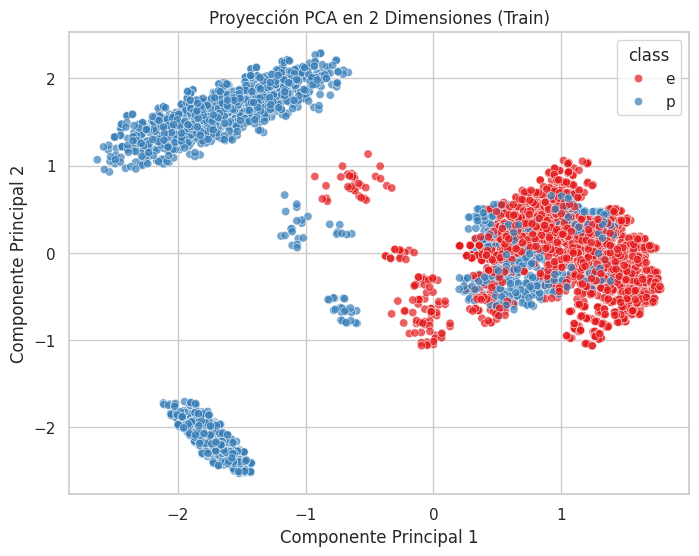

In [19]:

# metodo de sklearn
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train)
# Representar en un scatterplot y poner en color las etiquetas de entrenamiento
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_train_pca[:, 0], y=X_train_pca[:, 1], hue=y_train, palette='Set1', alpha=0.7)
plt.title('Proyección PCA en 2 Dimensiones (Train)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.show()



Parece que está bastante separadito, ¡a ojo mucho se puede ver! :)

Antes de seguir, entrenamos un clasificador supervisado como **línea base** (así sabemos cuánta información hay realmente en los datos).

In [23]:
# 1. Definir el clasificador y el numero de estimadores
clf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
# 2. Entrenar en train
clf.fit(X_train, y_train)
# 3. Calcular la precision sobre test
Precision = clf.score(X_test, y_test)
print(f"Precisión en el conjunto de test: {Precision:.4f}")

Precisión en el conjunto de test: 1.0000


Es un conjunto sencillo y Random Forest es muy bueno. Veamos cuántas features tenemos:

In [24]:
X_train.shape

(5443, 115)

¿Muchas features, no? Vamos a reducirlas con PCA y ver cuántas componentes necesita Random Forest para mantener su precisión.

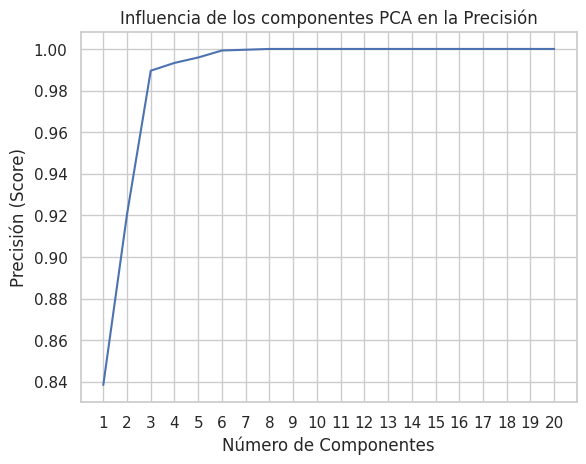

In [25]:

# definir un rango de valores a probar
n_features = range(1, 21)
scores = []

for n in n_features:
    # 1. Definir y ajustar PCA sobre X_train
    pca_n = PCA(n_components=n, random_state=RANDOM_STATE)
    X_train_pca_n = pca_n.fit_transform(X_train)
    X_test_pca_n = pca_n.transform(X_test)
    # 2. Entrenar Random Forest sobre los datos reducidos
    rf_n = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
    rf_n.fit(X_train_pca_n, y_train)
    # 3. Guardar el score en test
    scores.append(rf_n.score(X_test_pca_n, y_test))

sns.lineplot(x=list(n_features), y=scores)
plt.title('Influencia de los componentes PCA en la Precisión')
plt.xlabel('Número de Componentes')
plt.ylabel('Precisión (Score)')
plt.xticks(list(n_features))
plt.show()

A partir de ~10 componentes ya tenemos la precisión que queríamos, reduciendo las variables a una fracción de las originales.

---
## t-SNE: reducción **no lineal** para visualizar

PCA es lineal. **t-SNE** intenta preservar la vecindad local y suele separar mejor los grupos visualmente. Es más caro, así que lo calculamos sobre una **muestra**.

In [ ]:
# 1. Tomar una muestra de X_train (t-SNE es lento)
# 2. Definir TSNE(n_components=2, ...) y ajustar
# 3. Pintar el embedding coloreado por la etiqueta

---
## Clustering

El conjunto es sencillito, así que probemos clustering para ver qué información obtenemos **sin usar las etiquetas**. Trabajaremos sobre una representación reducida con PCA (10 componentes), que limpia ruido y acelera los algoritmos.

In [ ]:
# Reducir X (one-hot completo) a 10 componentes con PCA -> X_red

### K-Means: ¿cuántos clusters? Codo + Silhouette

El **método del codo** mira la inercia (suma de distancias a los centroides). El **coeficiente de silhouette** mide cómo de bien separados están los clusters (cuanto más alto, mejor). Usamos ambos.

In [ ]:
from sklearn.cluster import KMeans

k_values = # definir un rango
inercias, silhouettes = [], []
for k in k_values:
    # Definir KMeans y ajustar sobre X_red
    # Guardar la inercia (km.inertia_) y el silhouette_score

# Pintar las dos curvas (codo y silhouette)

### K-Means final y comparación con la etiqueta

Sabemos que hay dos clases (comestible / venenosa), así que probamos `k=2`. Con `catplot` vemos la distribución de la etiqueta real dentro de cada cluster.

In [ ]:
# Aprender KMeans con el k obtenido y preparar el catplot.
kmeans = # Definir y entrenar KMeans

# ax = sns.catplot(col=, x=, data=, kind='count', col_wrap=4)
# Calcular ARI y NMI frente a y_bin

> **ARI / NMI** comparan los clusters con la etiqueta real (0 = aleatorio, 1 = idéntico). Sin haber visto la etiqueta, K-Means recupera buena parte de la estructura comestible/venenosa, pero **no es perfecto**: ese es el reto real del no supervisado.

### Comparativa de algoritmos de clustering

Vamos a poner a competir **K-Means, Aglomerativo, GMM y DBSCAN** con varias métricas. Las tres primeras métricas son *internas* (no usan etiqueta); ARI sí la usa, para validar.

In [ ]:
# Definir una funcion evaluar(nombre, labels, X) que devuelva silhouette,
# davies_bouldin, calinski_harabasz y ARI.
# Aplicarla a KMeans, AgglomerativeClustering, GaussianMixture y DBSCAN
# y montar una tabla (DataFrame) comparativa.

### Dendrograma (clustering jerárquico)

El clustering aglomerativo construye una jerarquía que podemos visualizar como **dendrograma**. La altura a la que se unen dos grupos indica cómo de distintos son. Lo calculamos sobre una muestra para que se lea bien.

In [ ]:
# 1. Tomar una muestra de X_red
# 2. linkage(..., method='ward')
# 3. dendrogram(...) para visualizar la jerarquia

### DBSCAN: la **métrica de distancia importa**

DBSCAN agrupa por densidad. Pero con datos **categóricos** codificados en one-hot, la distancia euclídea no captura bien la similitud. Comparemos euclídea (sobre PCA) con la distancia de **Jaccard** (pensada para datos binarios).

In [ ]:
# Comparar DBSCAN con metric='euclidean' (sobre X_red) y metric='jaccard'
# (sobre el one-hot binario). Observar cual recupera mejor la estructura (ARI).

> **Lección:** con datos categóricos, elegir la distancia adecuada (Jaccard/Hamming) puede cambiar por completo el resultado de un algoritmo basado en densidad. No hay un algoritmo que gane siempre: depende del tipo de datos.

### Visualización final: clusters vs etiqueta real

Repetimos el scatter PCA, pero coloreando por el cluster de K-Means y por la etiqueta real, lado a lado.

In [ ]:
# Entrenar PCA(2) sobre X para representar.
# Pintar dos scatter: uno coloreado por el cluster de KMeans y otro por la etiqueta real.

Es bastante parecido, ¿no? No es tan bueno como Random Forest (que usa etiquetas), pero K-Means ha identificado bastante bien la estructura **sin usarlas**. Si no tuviéramos etiquetas, esta aproximación nos ayudaría mucho a clasificar los tipos de hongos.

---
## Detección de anomalías (Isolation Forest)

Una tarea no supervisada distinta: encontrar las muestras **atípicas**. Isolation Forest aísla los puntos raros con pocos cortes aleatorios.

In [ ]:
# 1. Definir IsolationForest(contamination=...) y ajustar sobre X_red
# 2. predict -> -1 son anomalias
# 3. Pintarlas sobre la proyeccion PCA

---
## Para ir más allá (opcional)

- **UMAP** (`pip install umap-learn`): alternativa a t-SNE, más rápida y preserva mejor la estructura global.
- **HDBSCAN** (`pip install hdbscan`): DBSCAN jerárquico que no necesita fijar `eps`.
- **Reglas de asociación** (`mlxtend`, Apriori/FP-Growth): muy naturales aquí por ser datos categóricos; permiten descubrir reglas tipo «si olor = X entonces venenosa».

## Conclusiones

- PCA y t-SNE nos dejaron *ver* un dataset de >100 dimensiones.
- K-Means, GMM y Aglomerativo recuperan la estructura comestible/venenosa con ARI ~0.6 **sin usar la etiqueta**.
- DBSCAN nos enseñó que **la métrica de distancia importa** con datos categóricos.
- Isolation Forest localiza las setas más atípicas.
- El no supervisado no da una respuesta «perfecta», pero descubre estructura muy útil cuando no tenemos etiquetas.